In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 3000

x1 = np.random.uniform(-2, 2, N)
x2 = np.random.uniform(-2, 2, N)

X = np.column_stack((x1, x2))
y = ((x1**2 + x2**2) > 1.5).astype(int).reshape(-1, 1)

In [3]:
perm = np.random.permutation(N)
X = X[perm]
y = y[perm]

n_train = int(0.7 * N)
n_val = int(0.15 * N)

X_train = X[:n_train]
y_train = y[:n_train]

X_val = X[n_train:n_train+n_val]
y_val = y[n_train:n_train+n_val]

X_test = X[n_train+n_val:]
y_test = y[n_train+n_val:]

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def dsigmoid(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def drelu(z):
    return (z > 0).astype(float)

In [5]:
def bce_loss(y, y_hat):
    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1-eps)
    return -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))

def accuracy(y, y_hat):
    y_bin = (y_hat >= 0.5).astype(int)
    return np.mean(y_bin == y)

In [6]:
def initialize(layer_dims):
    params = {}
    L = len(layer_dims) - 1
    for l in range(1, L+1):
        params["W"+str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.1
        params["b"+str(l)] = np.zeros((layer_dims[l], 1))
    return params

In [7]:
def forward(X, params, hidden_activation):
    cache = {}
    A = X.T
    L = len(params)//2

    for l in range(1, L):
        Z = params["W"+str(l)] @ A + params["b"+str(l)]
        A = hidden_activation(Z)
        cache["Z"+str(l)] = Z
        cache["A"+str(l)] = A

    ZL = params["W"+str(L)] @ A + params["b"+str(L)]
    AL = sigmoid(ZL)

    cache["Z"+str(L)] = ZL
    cache["A"+str(L)] = AL

    return AL.T, cache

In [8]:
def backward(X, y, params, cache, hidden_deriv):
    grads = {}
    L = len(params)//2
    m = X.shape[0]

    AL = cache["A"+str(L)]
    dZ = AL - y.T

    for l in reversed(range(1, L+1)):
        A_prev = X.T if l==1 else cache["A"+str(l-1)]

        grads["dW"+str(l)] = (1/m) * dZ @ A_prev.T
        grads["db"+str(l)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        if l > 1:
            dA_prev = params["W"+str(l)].T @ dZ
            dZ = dA_prev * hidden_deriv(cache["Z"+str(l-1)])

    return grads

In [9]:
def update_sgd(params, grads, lr):
    for key in params:
        params[key] -= lr * grads["d"+key]

def update_momentum(params, grads, velocity, lr, beta=0.9):
    for key in params:
        if key not in velocity:
            velocity[key] = np.zeros_like(params[key])
        velocity[key] = beta*velocity[key] + lr*grads["d"+key]
        params[key] -= velocity[key]
    return velocity

In [10]:
def train_model(layer_dims, hidden_activation, hidden_deriv,
                optimizer="sgd", lr=0.05, epochs=200):

    params = initialize(layer_dims)
    velocity = {}
    grads = None

    train_loss_list = []
    val_loss_list = []
    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):

        y_hat_train, cache = forward(X_train, params, hidden_activation)
        loss_train = bce_loss(y_train, y_hat_train)
        acc_train = accuracy(y_train, y_hat_train)

        grads = backward(X_train, y_train, params, cache, hidden_deriv)

        if optimizer == "sgd":
            update_sgd(params, grads, lr)
        else:
            velocity = update_momentum(params, grads, velocity, lr)

        y_hat_val, _ = forward(X_val, params, hidden_activation)
        loss_val = bce_loss(y_val, y_hat_val)
        acc_val = accuracy(y_val, y_hat_val)

        train_loss_list.append(loss_train)
        val_loss_list.append(loss_val)
        train_acc_list.append(acc_train)
        val_acc_list.append(acc_val)

    return params, train_loss_list, val_loss_list, train_acc_list, val_acc_list, grads

In [11]:
def count_parameters(layer_dims):
    total = 0
    for i in range(len(layer_dims)-1):
        total += layer_dims[i]*layer_dims[i+1] + layer_dims[i+1]
    return total

In [12]:
architectures = {
    "2-layer": [2,8,1],
    "5-layer": [2,8,8,8,8,1],
    "10-layer": [2,8,8,8,8,8,8,8,8,8,1]
}

activations = {
    "ReLU": (relu, drelu),
    "Sigmoid": (sigmoid, dsigmoid)
}

optimizers = ["sgd", "momentum"]

results = []

for arch_name, layer_dims in architectures.items():
    for act_name, (act, dact) in activations.items():
        for opt in optimizers:

            print(f"\nTraining {arch_name} | {act_name} | {opt}")

            params, train_loss, val_loss, train_acc, val_acc, final_grads = train_model(
                layer_dims,
                act,
                dact,
                optimizer=opt
            )

            y_hat_test, _ = forward(X_test, params, act)

            test_loss = bce_loss(y_test, y_hat_test)
            test_acc = accuracy(y_test, y_hat_test)

            results.append([
                arch_name,
                act_name,
                opt,
                count_parameters(layer_dims),
                train_acc[-1],
                val_acc[-1],
                test_acc
            ])


Training 2-layer | ReLU | sgd

Training 2-layer | ReLU | momentum

Training 2-layer | Sigmoid | sgd

Training 2-layer | Sigmoid | momentum

Training 5-layer | ReLU | sgd

Training 5-layer | ReLU | momentum

Training 5-layer | Sigmoid | sgd

Training 5-layer | Sigmoid | momentum

Training 10-layer | ReLU | sgd

Training 10-layer | ReLU | momentum

Training 10-layer | Sigmoid | sgd

Training 10-layer | Sigmoid | momentum


In [13]:
print("\nRESULT TABLE\n")

print("{:<10} {:<10} {:<10} {:<10} {:<12} {:<10} {:<10} {:<10}".format(
    "Model","Depth","Act","Opt","Params","TrainAcc","ValAcc","TestAcc"))

print("-"*100)

for r in results:
    arch, act, opt, params_count, tr_acc, val_acc, test_acc = r
    depth = len(architectures[arch]) - 1

    print("{:<10} {:<10} {:<10} {:<10} {:<12} {:.4f}     {:.4f}     {:.4f}".format(
        arch, depth, act, opt,
        params_count,
        tr_acc, val_acc, test_acc))


RESULT TABLE

Model      Depth      Act        Opt        Params       TrainAcc   ValAcc     TestAcc   
----------------------------------------------------------------------------------------------------
2-layer    2          ReLU       sgd        33           0.7157     0.7022     0.6978
2-layer    2          ReLU       momentum   33           0.8429     0.8267     0.8400
2-layer    2          Sigmoid    sgd        33           0.7157     0.7022     0.6978
2-layer    2          Sigmoid    momentum   33           0.7157     0.7022     0.6978
5-layer    5          ReLU       sgd        249          0.7157     0.7022     0.6978
5-layer    5          ReLU       momentum   249          0.7157     0.7022     0.6978
5-layer    5          Sigmoid    sgd        249          0.7157     0.7022     0.6978
5-layer    5          Sigmoid    momentum   249          0.7157     0.7022     0.6978
10-layer   10         ReLU       sgd        609          0.7157     0.7022     0.6978
10-layer   10       

In [15]:
print("\nGradient Norm Comparison (Sigmoid 2-layer vs 10-layer)\n")

params2, _, _, _, _, grads2 = train_model([2,8,1], sigmoid, dsigmoid)
grad2_L1 = np.linalg.norm(grads2["dW1"])
grad2_last = np.linalg.norm(grads2["dW2"])

params10, _, _, _, _, grads10 = train_model(
    [2,8,8,8,8,8,8,8,8,8,1],
    sigmoid,
    dsigmoid
)

grad10_L1 = np.linalg.norm(grads10["dW1"])
grad10_last = np.linalg.norm(grads10["dW10"])

print("2-layer Sigmoid - First Layer:", grad2_L1)
print("2-layer Sigmoid - Last Layer:", grad2_last)

print("\n10-layer Sigmoid - First Layer:", grad10_L1)
print("10-layer Sigmoid - Last Layer:", grad10_last)


Gradient Norm Comparison (Sigmoid 2-layer vs 10-layer)

2-layer Sigmoid - First Layer: 0.0011783172228818617
2-layer Sigmoid - Last Layer: 0.0006914097580454399

10-layer Sigmoid - First Layer: 5.473284267735633e-14
10-layer Sigmoid - Last Layer: 0.00039465549379034953


In [16]:
np.random.seed(42)

N = 3000
img_size = 8
sigma = 0.1

X_images = []
y_images = []

for i in range(N):
    img = np.zeros((img_size, img_size))

    if i < N//2:
        img[:, img_size//2] = 1
        y_images.append(0)
    else:
        img[img_size//2, :] = 1
        y_images.append(1)

    img += np.random.normal(0, sigma, (img_size, img_size))
    X_images.append(img)

X_images = np.array(X_images)
y_images = np.array(y_images).reshape(-1,1)

perm = np.random.permutation(N)
X_images = X_images[perm]
y_images = y_images[perm]

In [17]:
n_train = int(0.7*N)
n_val = int(0.15*N)

X_train_img = X_images[:n_train]
y_train_img = y_images[:n_train]

X_val_img = X_images[n_train:n_train+n_val]
y_val_img = y_images[n_train:n_train+n_val]

X_test_img = X_images[n_train+n_val:]
y_test_img = y_images[n_train+n_val:]

In [19]:
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_val_flat = X_val_img.reshape(len(X_val_img), -1)
X_test_flat = X_test_img.reshape(len(X_test_img), -1)

dense_arch = [64, 32, 1]

_original_X_train = X_train
_original_y_train = y_train
_original_X_val = X_val
_original_y_val = y_val

X_train = X_train_flat
y_train = y_train_img
X_val = X_val_flat
y_val = y_val_img

params_dense, tl, vl, ta, va, _ = train_model(
    dense_arch,
    relu,
    drelu,
    optimizer="sgd",
    lr=0.01,
    epochs=200
)

X_train = _original_X_train
y_train = _original_y_train
X_val = _original_X_val
y_val = _original_y_val

y_hat_test_dense, _ = forward(X_test_flat, params_dense, relu)

dense_test_acc = accuracy(y_test_img, y_hat_test_dense)
dense_test_loss = bce_loss(y_test_img, y_hat_test_dense)

print("\nDense Baseline Test Accuracy:", dense_test_acc)
print("Dense Baseline Test Loss:", dense_test_loss)


Dense Baseline Test Accuracy: 1.0
Dense Baseline Test Loss: 0.44333103599362705


In [20]:
def conv_forward(X, K):
    n, h, w = X.shape
    f = K.shape[0]
    out_dim = h - f + 1
    out = np.zeros((n, out_dim, out_dim))

    for i in range(n):
        for r in range(out_dim):
            for c in range(out_dim):
                region = X[i, r:r+f, c:c+f]
                out[i,r,c] = np.sum(region * K)
    return out

In [21]:
def max_pool(X, size=2):
    n, h, w = X.shape
    out_dim = h // size
    out = np.zeros((n, out_dim, out_dim))

    for i in range(n):
        for r in range(out_dim):
            for c in range(out_dim):
                region = X[i, r*size:(r+1)*size, c*size:(c+1)*size]
                out[i,r,c] = np.max(region)
    return out

In [22]:
K = np.random.randn(3,3) * 0.1

W_fc = np.random.randn(1,9)*0.1
b_fc = np.zeros((1,1))

lr = 0.01

for epoch in range(200):

    conv_out = conv_forward(X_train_img, K)
    relu_out = relu(conv_out)
    pool_out = max_pool(relu_out)

    flat = pool_out.reshape(len(pool_out), -1)

    z = flat @ W_fc.T + b_fc
    y_hat = sigmoid(z)

    loss = bce_loss(y_train_img, y_hat)

    dZ = y_hat - y_train_img
    dW_fc = (1/len(flat)) * dZ.T @ flat
    db_fc = np.mean(dZ)

    W_fc -= lr * dW_fc
    b_fc -= lr * db_fc

conv_out_test = conv_forward(X_test_img, K)
relu_out_test = relu(conv_out_test)
pool_out_test = max_pool(relu_out_test)
flat_test = pool_out_test.reshape(len(pool_out_test), -1)

z_test = flat_test @ W_fc.T + b_fc
y_hat_test_cnn = sigmoid(z_test)

cnn_test_acc = accuracy(y_test_img, y_hat_test_cnn)
cnn_test_loss = bce_loss(y_test_img, y_hat_test_cnn)

print("\nCNN Test Accuracy:", cnn_test_acc)
print("CNN Test Loss:", cnn_test_loss)


CNN Test Accuracy: 0.5155555555555555
CNN Test Loss: 0.676889564585076


In [23]:
def dropout(A, p=0.5):
    mask = (np.random.rand(*A.shape) > p)
    return A * mask

In [24]:
def train_cnn(optimizer="sgd", lr=0.01, epochs=200):

    K = np.random.randn(3,3) * 0.1
    W_fc = np.random.randn(1,9) * 0.1
    b_fc = np.zeros((1,1))

    vK = np.zeros_like(K)
    vW = np.zeros_like(W_fc)
    vb = np.zeros_like(b_fc)

    mK = np.zeros_like(K)
    vK_adam = np.zeros_like(K)

    mW = np.zeros_like(W_fc)
    vW_adam = np.zeros_like(W_fc)

    mb = np.zeros_like(b_fc)
    vb_adam = np.zeros_like(b_fc)

    beta = 0.9
    beta1 = 0.9
    beta2 = 0.999
    eps = 1e-8

    train_loss_list = []
    val_loss_list = []

    for epoch in range(epochs):

        conv_out = conv_forward(X_train_img, K)
        relu_out = relu(conv_out)
        pool_out = max_pool(relu_out)

        flat = pool_out.reshape(len(pool_out), -1)

        z = flat @ W_fc.T + b_fc
        y_hat = sigmoid(z)

        loss = bce_loss(y_train_img, y_hat)

        m = len(flat)
        dZ = y_hat - y_train_img

        dW_fc = (1/m) * dZ.T @ flat
        db_fc = np.mean(dZ)

        if optimizer == "sgd":

            W_fc -= lr * dW_fc
            b_fc -= lr * db_fc

        elif optimizer == "momentum":

            vW = beta*vW + lr*dW_fc
            vb = beta*vb + lr*db_fc

            W_fc -= vW
            b_fc -= vb

        elif optimizer == "adam":

            mW = beta1*mW + (1-beta1)*dW_fc
            mb = beta1*mb + (1-beta1)*db_fc

            vW_adam = beta2*vW_adam + (1-beta2)*(dW_fc**2)
            vb_adam = beta2*vb_adam + (1-beta2)*(db_fc**2)

            mW_hat = mW / (1 - beta1**(epoch+1))
            mb_hat = mb / (1 - beta1**(epoch+1))

            vW_hat = vW_adam / (1 - beta2**(epoch+1))
            vb_hat = vb_adam / (1 - beta2**(epoch+1))

            W_fc -= lr * mW_hat / (np.sqrt(vW_hat) + eps)
            b_fc -= lr * mb_hat / (np.sqrt(vb_hat) + eps)

        conv_val = conv_forward(X_val_img, K)
        relu_val = relu(conv_val)
        pool_val = max_pool(relu_val)
        flat_val = pool_val.reshape(len(pool_val), -1)

        z_val = flat_val @ W_fc.T + b_fc
        y_hat_val = sigmoid(z_val)

        val_loss = bce_loss(y_val_img, y_hat_val)

        train_loss_list.append(loss)
        val_loss_list.append(val_loss)

    conv_test = conv_forward(X_test_img, K)
    relu_test = relu(conv_test)
    pool_test = max_pool(relu_test)
    flat_test = pool_test.reshape(len(pool_test), -1)

    z_test = flat_test @ W_fc.T + b_fc
    y_hat_test = sigmoid(z_test)

    test_loss = bce_loss(y_test_img, y_hat_test)
    test_acc = accuracy(y_test_img, y_hat_test)

    return train_loss_list, val_loss_list, test_loss, test_acc


Training CNN with SGD

Training CNN with MOMENTUM

Training CNN with ADAM


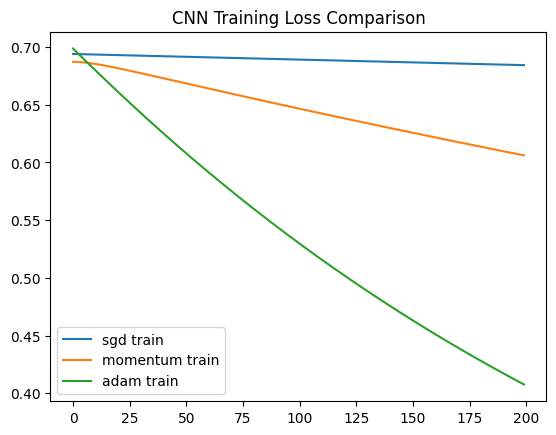


CNN Optimizer Comparison

Optimizer: sgd | Test Loss: 0.6842 | Test Acc: 1.0000
Optimizer: momentum | Test Loss: 0.6067 | Test Acc: 1.0000
Optimizer: adam | Test Loss: 0.4055 | Test Acc: 1.0000


In [25]:
optimizers = ["sgd", "momentum", "adam"]

cnn_results = []

for opt in optimizers:
    print(f"\nTraining CNN with {opt.upper()}")
    tl, vl, test_loss, test_acc = train_cnn(
        optimizer=opt,
        lr=0.01,
        epochs=200
    )

    cnn_results.append([opt, test_loss, test_acc])
    plt.plot(tl, label=f"{opt} train")

plt.title("CNN Training Loss Comparison")
plt.legend()
plt.show()

print("\nCNN Optimizer Comparison\n")

for r in cnn_results:
    print(f"Optimizer: {r[0]} | Test Loss: {r[1]:.4f} | Test Acc: {r[2]:.4f}")

In [27]:
import pandas as pd

columns = [
    "Model",
    "Activation",
    "Optimizer",
    "Parameters",
    "Train Accuracy",
    "Validation Accuracy",
    "Test Accuracy"
]

master_df = pd.DataFrame(results, columns=columns)

def get_depth(model_name):
    if "2-layer" in model_name:
        return 2
    elif "5-layer" in model_name:
        return 5
    elif "10-layer" in model_name:
        return 10

master_df["Depth"] = master_df["Model"].apply(get_depth)

master_df = master_df[
    ["Model", "Depth", "Activation", "Optimizer",
     "Parameters", "Train Accuracy",
     "Validation Accuracy", "Test Accuracy"]
]

print("\nMASTER RESULT TABLE\n")
print(master_df)

master_df.to_csv("master_result_table.csv", index=False)


MASTER RESULT TABLE

       Model  Depth Activation Optimizer  Parameters  Train Accuracy  \
0    2-layer      2       ReLU       sgd          33        0.715714   
1    2-layer      2       ReLU  momentum          33        0.842857   
2    2-layer      2    Sigmoid       sgd          33        0.715714   
3    2-layer      2    Sigmoid  momentum          33        0.715714   
4    5-layer      5       ReLU       sgd         249        0.715714   
5    5-layer      5       ReLU  momentum         249        0.715714   
6    5-layer      5    Sigmoid       sgd         249        0.715714   
7    5-layer      5    Sigmoid  momentum         249        0.715714   
8   10-layer     10       ReLU       sgd         609        0.715714   
9   10-layer     10       ReLU  momentum         609        0.715714   
10  10-layer     10    Sigmoid       sgd         609        0.715714   
11  10-layer     10    Sigmoid  momentum         609        0.715714   

    Validation Accuracy  Test Accuracy  


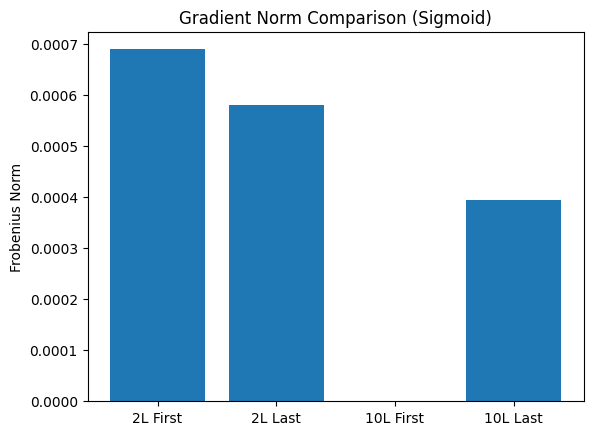

In [29]:
import matplotlib.pyplot as plt

_, _, _, _, _, grads_2 = train_model(
    [2,8,1],
    sigmoid,
    dsigmoid,
    optimizer="sgd"
)

_, _, _, _, _, grads_10 = train_model(
    [2,8,8,8,8,8,8,8,8,8,1],
    sigmoid,
    dsigmoid,
    optimizer="sgd"
)

grad2_first = np.linalg.norm(grads_2["dW1"])
grad2_last = np.linalg.norm(grads_2["dW2"])

grad10_first = np.linalg.norm(grads10["dW1"])
grad10_last = np.linalg.norm(grads10["dW10"])

plt.bar(["2L First","2L Last","10L First","10L Last"],
        [grad2_first, grad2_last, grad10_first, grad10_last])

plt.title("Gradient Norm Comparison (Sigmoid)")
plt.ylabel("Frobenius Norm")
plt.show()

In [30]:
def train_cnn_no_pool(epochs=200, lr=0.01):

    K = np.random.randn(3,3) * 0.1
    W_fc = np.random.randn(1,36) * 0.1   # 6x6 after conv
    b_fc = np.zeros((1,1))

    train_loss = []

    for epoch in range(epochs):
        conv_out = conv_forward(X_train_img, K)
        relu_out = relu(conv_out)
        flat = relu_out.reshape(len(relu_out), -1)
        z = flat @ W_fc.T + b_fc
        y_hat = sigmoid(z)
        loss = bce_loss(y_train_img, y_hat)
        dZ = y_hat - y_train_img
        dW = (1/len(flat)) * dZ.T @ flat
        db = np.mean(dZ)
        W_fc -= lr * dW
        b_fc -= lr * db

        train_loss.append(loss)

    return train_loss

In [31]:
def dropout(A, p=0.5):
    mask = (np.random.rand(*A.shape) > p)
    return A * mask

def train_cnn_dropout(epochs=200, lr=0.01):
    K = np.random.randn(3,3) * 0.1
    W_fc = np.random.randn(1,9) * 0.1
    b_fc = np.zeros((1,1))

    train_loss = []

    for epoch in range(epochs):
        conv_out = conv_forward(X_train_img, K)
        relu_out = relu(conv_out)
        pool_out = max_pool(relu_out)
        drop_out = dropout(pool_out, p=0.5)
        flat = drop_out.reshape(len(drop_out), -1)
        z = flat @ W_fc.T + b_fc
        y_hat = sigmoid(z)
        loss = bce_loss(y_train_img, y_hat)
        dZ = y_hat - y_train_img
        dW = (1/len(flat)) * dZ.T @ flat
        db = np.mean(dZ)
        W_fc -= lr * dW
        b_fc -= lr * db

        train_loss.append(loss)

    return train_loss

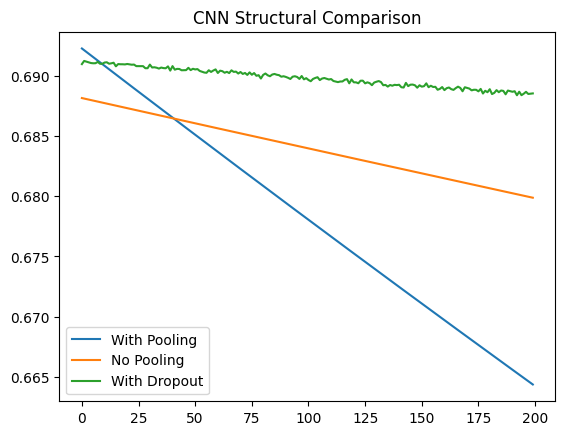

In [32]:
loss_pool, _, _, _ = train_cnn(optimizer="sgd")
loss_no_pool = train_cnn_no_pool()
loss_dropout = train_cnn_dropout()

plt.plot(loss_pool, label="With Pooling")
plt.plot(loss_no_pool, label="No Pooling")
plt.plot(loss_dropout, label="With Dropout")

plt.title("CNN Structural Comparison")
plt.legend()
plt.show()

In [33]:
print("\nParameter Derivation (CNN)")
print("Conv Layer: (3x3x1) + 1 = 10")
print("After pooling: 3x3 = 9 units")
print("FC Layer: (9x1) + 1 = 10")
print("Total CNN Parameters = 20")

print("\nDense Baseline Parameters:")
print("(64x32 + 32) + (32x1 + 1) = 2113")


Parameter Derivation (CNN)
Conv Layer: (3x3x1) + 1 = 10
After pooling: 3x3 = 9 units
FC Layer: (9x1) + 1 = 10
Total CNN Parameters = 20

Dense Baseline Parameters:
(64x32 + 32) + (32x1 + 1) = 2113
